https://www.kaggle.com/datasets/mikeytracegod/lung-cancer-risk-dataset

# Conjunto de dados de risco de câncer de pulmão
Um conjunto de dados limpo e pré-processado com 50.000 perfis de pacientes para risco de câncer de pulmão

# Conjunto de dados de risco de câncer de pulmão

**Visão geral**

Este conjunto de dados contém 50.000 perfis de pacientes projetados para análise de risco de câncer de pulmão e aplicações de aprendizado de máquina. O conjunto de dados é limpo, pré-processado e pronto para uso imediato em tarefas de classificação, análise estatística e visualização de dados.

Linhas : 50.000
Colunas : 11
Arquivo :preprocessed_lung_cancer_dataset.csv
Licença : CC0: Domínio Público
Descrição do conjunto de dados
O conjunto de dados inclui perfis de pacientes com características baseadas em fatores de risco estabelecidos para câncer de pulmão, como histórico de tabagismo, exposições ambientais e doenças pulmonares crônicas. Todos os dados são sintéticos e projetados para refletir distribuições realistas de fatores de risco, preservando a privacidade do paciente.

# Descrição do conjunto de dados

O conjunto de dados inclui perfis de pacientes com características baseadas em fatores de risco estabelecidos para câncer de pulmão, como histórico de tabagismo, exposições ambientais e doenças pulmonares crônicas. Todos os dados são sintéticos e projetados para refletir distribuições realistas de fatores de risco, preservando a privacidade do paciente.

# Características

Coluna	Tipo	Descrição	Valores/Intervalo
id_do_paciente	Inteiro	Identificador único do paciente	100000-149999
idade	Inteiro	Idade do paciente em anos	18-100
gênero	Corda	Sexo do paciente	'Masculino', 'Feminino'
anos_embalagem	Flutuador	Exposição ao fumo (anos × maços por dia)	0-100
exposição ao radônio	Corda	Nível de exposição residencial ao radônio	'Baixo', 'Médio', 'Alto'
exposição ao amianto	Corda	Histórico de exposição ocupacional ao amianto	'Sim', 'Não'
exposição_à_fumaça_de_segunda_mão	Corda	Exposição ao fumo passivo	'Sim', 'Não'
diagnóstico_de_DPOC	Corda	Diagnóstico de doença pulmonar obstrutiva crônica	'Sim', 'Não'
consumo_de_álcool	Corda	Padrão de consumo de álcool	'Nenhum', 'Moderado', 'Pesado'
história_familiar	Corda	Histórico familiar de câncer de pulmão	'Sim', 'Não'
câncer de pulmão	Corda	Variável alvo : Diagnóstico de câncer de pulmão	'Sim', 'Não'

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

df_lung = pd.read_csv('lung_cancer_dataset.csv')

In [2]:
df_lung

,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,No,No,Yes,Moderate,No,No
1,100001,32,Female,12.780800,High,No,Yes,Yes,Moderate,Yes,Yes
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
3,100003,78,Female,44.065232,Low,No,Yes,No,Moderate,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...
49995,149995,81,Female,9.386431,Medium,No,Yes,No,Moderate,No,Yes
49996,149996,28,Male,99.471718,Medium,No,Yes,No,Moderate,No,Yes
49997,149997,90,Male,14.349722,Low,Yes,Yes,No,Heavy,Yes,Yes
49998,149998,33,Female,87.012555,Medium,No,No,Yes,Moderate,No,No


In [3]:
#Informações
df_lung.info()
df_lung.head()
df_lung.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50000 non-null  int64  
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   pack_years                 50000 non-null  float64
 4   radon_exposure             50000 non-null  object 
 5   asbestos_exposure          50000 non-null  object 
 6   secondhand_smoke_exposure  50000 non-null  object 
 7   copd_diagnosis             50000 non-null  object 
 8   alcohol_consumption        33338 non-null  object 
 9   family_history             50000 non-null  object 
 10  lung_cancer                50000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.2+ MB


,patient_id,age,pack_years
count,50000.000000,50000.000000,50000.000000
mean,124999.500000,58.857040,49.963424
std,14433.901067,23.958266,28.852082
min,100000.000000,18.000000,0.002753
25%,112499.750000,38.000000,24.774558
50%,124999.500000,59.000000,50.177634
75%,137499.250000,80.000000,75.066740
max,149999.000000,100.000000,99.999204


In [4]:
#Valores nulos
df_lung.isna().sum()

patient_id                       0
age                              0
gender                           0
pack_years                       0
radon_exposure                   0
asbestos_exposure                0
secondhand_smoke_exposure        0
copd_diagnosis                   0
alcohol_consumption          16662
family_history                   0
lung_cancer                      0
dtype: int64

In [5]:
#Moda para a coluna 'alcohol_consumption'
moda_alcohol = df_lung['alcohol_consumption'].mode()[0]

df_lung['alcohol_consumption'].fillna(moda_alcohol, inplace=True)

print("Contagem de valores nulos após o tratamento:")
print(df_lung.isna().sum())

Contagem de valores nulos após o tratamento:
patient_id                   0
age                          0
gender                       0
pack_years                   0
radon_exposure               0
asbestos_exposure            0
secondhand_smoke_exposure    0
copd_diagnosis               0
alcohol_consumption          0
family_history               0
lung_cancer                  0
dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\2039251435.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_lung['alcohol_consumption'].fillna(moda_alcohol, inplace=True)


Contagem da variável alvo 'lung_cancer':
lung_cancer
Yes    34364
No     15636
Name: count, dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\1003504394.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='lung_cancer', data=df_lung, palette='Set2')


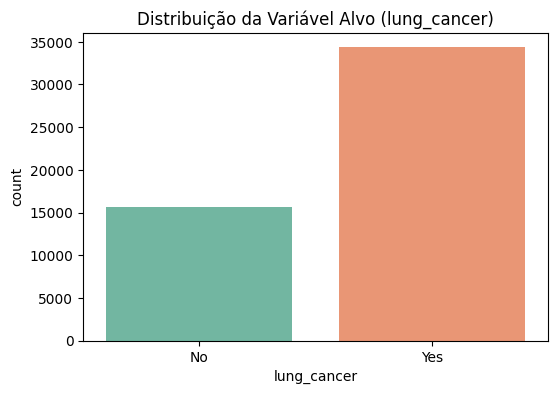

In [6]:
#Frequência das classes
target_counts = df_lung['lung_cancer'].value_counts()
print("Contagem da variável alvo 'lung_cancer':")
print(target_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='lung_cancer', data=df_lung, palette='Set2')
plt.title('Distribuição da Variável Alvo (lung_cancer)')
plt.show()

A variável alvo 'lung_cancer' (câncer de pulmão) é desbalanceada. Isso significa que a quantidade de casos de "Yes" (Sim) é significativamente maior do que a quantidade de casos de "No" (Não).

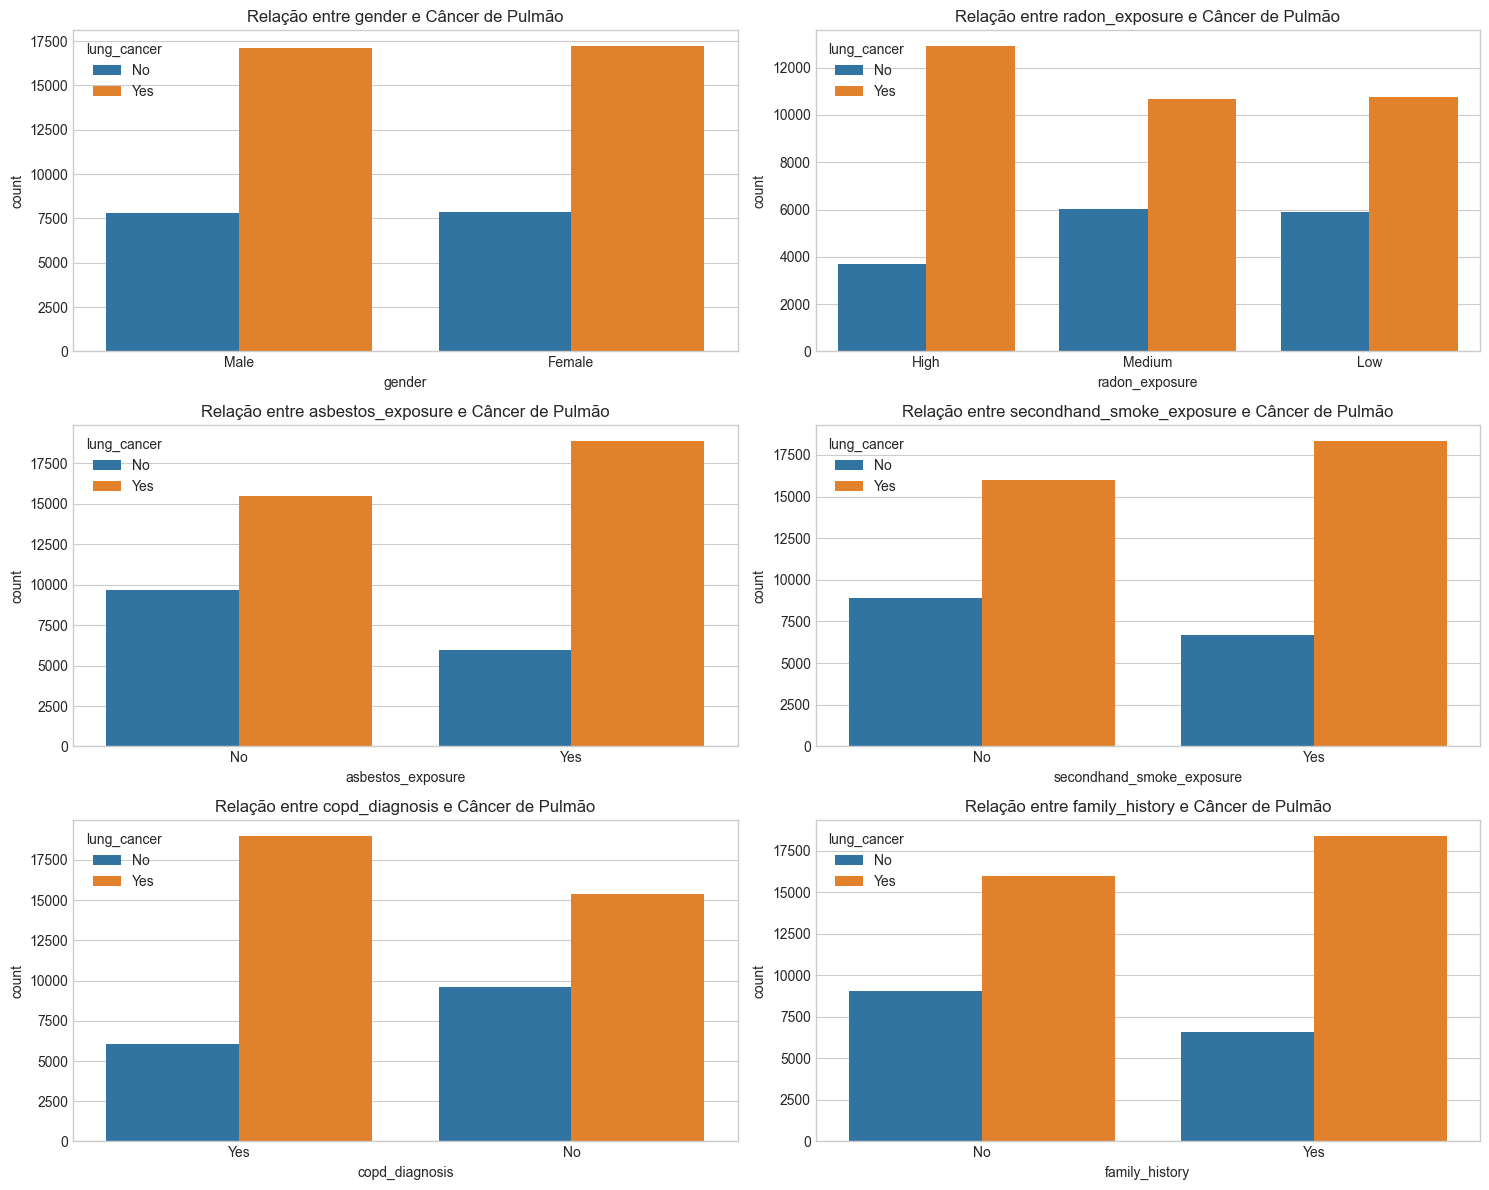

In [7]:
categorical_features = ['gender', 'radon_exposure', 'asbestos_exposure',
                        'secondhand_smoke_exposure', 'copd_diagnosis', 'family_history']

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_features):
    plt.subplot(3, 2, i + 1)
    sns.countplot(x=col, hue='lung_cancer', data=df_lung)
    plt.title(f'Relação entre {col} e Câncer de Pulmão')
    plt.tight_layout()

plt.show()

**Gênero (gender)**
"Relação entre gender e Câncer de Pulmão" mostra que a incidência de câncer de pulmão é maior no grupo feminino do que no grupo masculino.

**Exposição a Radônio (radon_exposure)**
"Relação entre radon_exposure e Câncer de Pulmão" sugere que, embora o câncer de pulmão ocorra em todos os níveis de exposição, a incidência de câncer de pulmão é mais alta em pessoas com alta e média exposição ao radônio, quando comparadas àquelas com baixa exposição.

**Exposição ao Amianto (asbestos_exposure)**
"Relação entre asbestos_exposure e Câncer de Pulmão" indica que pessoas expostas ao amianto ("Yes") têm uma incidência de câncer de pulmão significativamente mais alta do que aquelas que não foram expostas ("No").

**Fumo Passivo (secondhand_smoke_exposure)**
"Relação entre secondhand_smoke_exposure e Câncer de Pulmão" mostra uma incidência de câncer de pulmão muito maior em pessoas expostas ao fumo passivo ("Yes") em comparação com aquelas que não foram expostas ("No").

**Diagnóstico de DPOC (copd_diagnosis)**
"Relação entre copd_diagnosis e Câncer de Pulmão" revela uma forte associação. A incidência de câncer de pulmão é bem maior em indivíduos com diagnóstico de DPOC ("Yes") do que naqueles sem o diagnóstico ("No").

**Histórico Familiar (family_history)**
"Relação entre family_history e Câncer de Pulmão" demonstra que pessoas com histórico familiar de câncer de pulmão ("Yes") têm uma incidência de câncer de pulmão notavelmente maior do que aquelas sem histórico familiar ("No").

As variáveis analisadas (exposição ao amianto, fumo passivo, diagnóstico de DPOC e histórico familiar) estão fortemente associadas a uma maior incidência de câncer de pulmão. A exposição ao radônio também mostra uma associação, e o gênero feminino apresenta a maior incidência, em comparação com o masculino.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\4172058067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='lung_cancer', y='age', data=df_lung, palette='Set2')


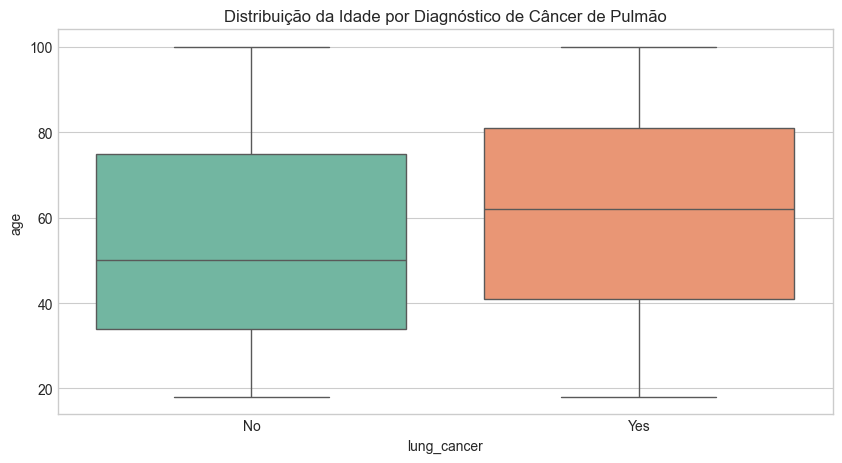

In [8]:
#Idade em relação ao diagnóstico de câncer de pulmão
plt.figure(figsize=(10, 5))
sns.boxplot(x='lung_cancer', y='age', data=df_lung, palette='Set2')
plt.title('Distribuição da Idade por Diagnóstico de Câncer de Pulmão')
plt.show()

A distribuição da idade em relação ao diagnóstico de câncer de pulmão é que, em média, as pessoas com câncer de pulmão são mais velhas do que aquelas sem a doença. Indicando uma clara tendência de que a idade é um fator de risco importante para o diagnóstico de câncer de pulmão.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\2581190103.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='lung_cancer', y='pack_years', data=df_lung, palette='mako')


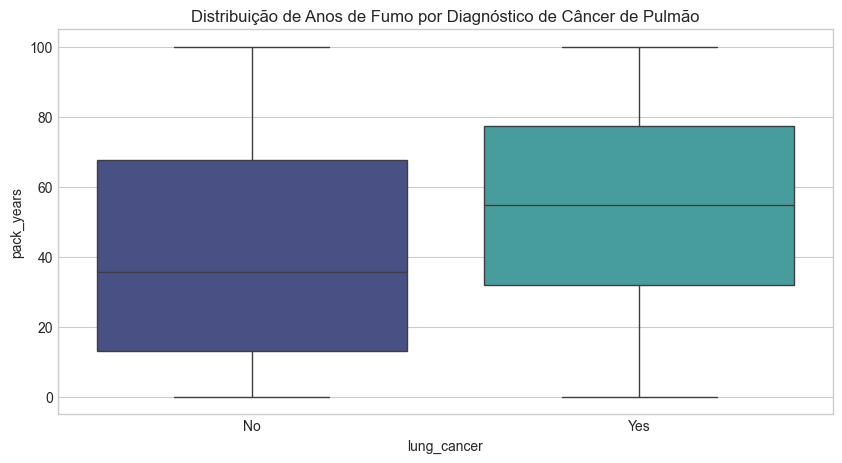

In [9]:
#Anos de fumo em relação ao diagnóstico de câncer de pulmão
plt.figure(figsize=(10, 5))
sns.boxplot(x='lung_cancer', y='pack_years', data=df_lung, palette='mako')
plt.title('Distribuição de Anos de Fumo por Diagnóstico de Câncer de Pulmão')
plt.show()

Indica uma forte associação entre a quantidade de anos de fumo e o diagnóstico de câncer de pulmão, sugerindo que o tempo de exposição ao tabagismo é um fator de risco importante.

In [10]:
#Heapmap
df_corr = pd.read_csv('lung_cancer_dataset.csv')
moda_alcohol = df_corr['alcohol_consumption'].mode()[0]
df_corr['alcohol_consumption'].fillna(moda_alcohol, inplace=True)

#Variáveis binárias
binario_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'High': 2, 'Medium': 1, 'Low': 0, 'Heavy': 2, 'Moderate': 1, 'None': 0}

for col in ['gender', 'radon_exposure', 'asbestos_exposure', 'secondhand_smoke_exposure',
            'copd_diagnosis', 'family_history', 'lung_cancer', 'alcohol_consumption']:
    df_corr[col] = df_corr[col].map(binario_map)
    
df_corr.head()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\3494900103.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_corr['alcohol_consumption'].fillna(moda_alcohol, inplace=True)


,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,1,66.025244,2,0,0,1,1,0,0
1,100001,32,0,12.780800,2,0,1,1,1,1,1
2,100002,89,0,0.408278,1,1,1,1,2,0,1
3,100003,78,0,44.065232,0,0,1,0,1,0,1
4,100004,38,0,44.432440,1,1,0,1,2,1,1


In [11]:
#Cramer V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramer_v_results = {}
for col in df_corr.columns.drop(['patient_id', 'age', 'pack_years', 'lung_cancer']):
    cramer_v_results[col] = cramers_v(df_corr[col], df_corr['lung_cancer'])

cramer_v_df = pd.DataFrame(cramer_v_results.items(), columns=['Feature', 'Cramer_V']).sort_values(by='Cramer_V', ascending=False)
print("Correlação de Cramer V com a variável alvo 'lung_cancer':")
print(cramer_v_df)

Correlação de Cramer V com a variável alvo 'lung_cancer':
                     Feature  Cramer_V
2          asbestos_exposure  0.157255
4             copd_diagnosis  0.153443
1             radon_exposure  0.136411
6             family_history  0.106739
3  secondhand_smoke_exposure  0.096744
5        alcohol_consumption  0.011225
0                     gender  0.000000


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\3127623132.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cramer_V', y='Feature', data=all_correlations.reset_index(), palette='Set3')


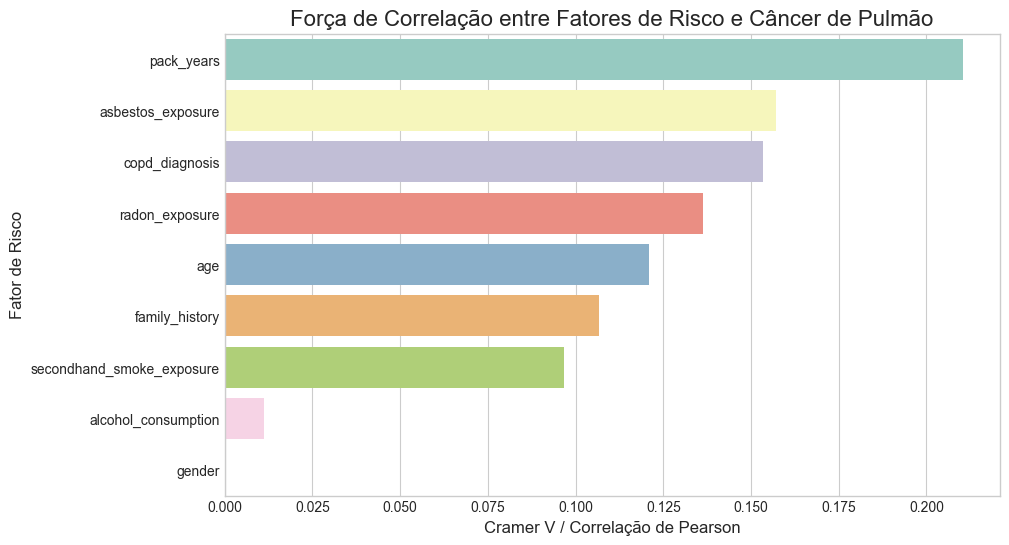

In [12]:
#Pearson
numeric_cols = ['age', 'pack_years', 'lung_cancer']
numeric_corr = df_corr[numeric_cols].corr()

all_correlations = cramer_v_df.set_index('Feature')
all_correlations.loc['age'] = numeric_corr.loc['age', 'lung_cancer']
all_correlations.loc['pack_years'] = numeric_corr.loc['pack_years', 'lung_cancer']
all_correlations = all_correlations.sort_values(by='Cramer_V', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Cramer_V', y='Feature', data=all_correlations.reset_index(), palette='Set3')
plt.title('Força de Correlação entre Fatores de Risco e Câncer de Pulmão', fontsize=16)
plt.xlabel('Cramer V / Correlação de Pearson', fontsize=12)
plt.ylabel('Fator de Risco', fontsize=12)
plt.show()

Indica que o tabagismo, a exposição ao amianto e a DPOC são os fatores mais fortemente associados ao câncer de pulmão, enquanto o consumo de álcool e o gênero têm a menor correlação.

In [13]:
df_model = pd.read_csv('lung_cancer_dataset.csv')
moda_alcohol = df_model['alcohol_consumption'].mode()[0]
df_model['alcohol_consumption'].fillna(moda_alcohol, inplace=True)

X = df_model.drop(['patient_id', 'lung_cancer'], axis=1)
y = df_model['lung_cancer'].map({'Yes': 1, 'No': 0}) 

categorical_cols = X.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = pd.DataFrame(encoder.fit_transform(X[categorical_cols]))

X_encoded.columns = encoder.get_feature_names_out(categorical_cols)

X_final = pd.concat([X.drop(categorical_cols, axis=1), X_encoded], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensões dos dados de treino:", X_train.shape)
print("Dimensões dos dados de teste:", X_test.shape)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\1130456498.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['alcohol_consumption'].fillna(moda_alcohol, inplace=True)


Dimensões dos dados de treino: (40000, 17)
Dimensões dos dados de teste: (10000, 17)


In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.61      0.34      0.43      3127
           1       0.75      0.90      0.82      6873

    accuracy                           0.73     10000
   macro avg       0.68      0.62      0.63     10000
weighted avg       0.71      0.73      0.70     10000

ROC AUC Score: 0.7425


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy.stats import ttest_ind
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [16]:
numerical_features = ['age', 'pack_years']
categorical_features = ['gender', 'radon_exposure', 'asbestos_exposure',
                        'secondhand_smoke_exposure', 'copd_diagnosis',
                        'alcohol_consumption', 'family_history']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipeline.fit(X, y)

print("ipeline de machine learning criado e treinado com sucesso!")

ipeline de machine learning criado e treinado com sucesso!


In [17]:
df_stats = pd.read_csv('lung_cancer_dataset.csv')
moda_alcohol = df_stats['alcohol_consumption'].mode()[0]
df_stats['alcohol_consumption'].fillna(moda_alcohol, inplace=True)

categorical_features = ['gender', 'radon_exposure', 'asbestos_exposure',
                        'secondhand_smoke_exposure', 'copd_diagnosis',
                        'alcohol_consumption', 'family_history']

print("Testes de Qui-quadrado para Fatores de Risco Categóricos:")
print("---------------------------------------------------------")

for col in categorical_features:
   
    contingency_table = pd.crosstab(df_stats[col], df_stats['lung_cancer'])
    
    
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    
    
    print(f"Variável: {col}")
    print(f"  Estatística Qui-quadrado: {chi2:.2f}")
    print(f"  Valor-p: {p_value:.4f}")
    
    if p_value < 0.05:
        print("  -> A associação é estatisticamente significativa (p < 0.05).")
    else:
        print("  -> Não há evidência de associação estatisticamente significativa.")
    print("-" * 57)

Testes de Qui-quadrado para Fatores de Risco Categóricos:
---------------------------------------------------------
Variável: gender
  Estatística Qui-quadrado: 0.00
  Valor-p: 0.9859
  -> Não há evidência de associação estatisticamente significativa.
---------------------------------------------------------
Variável: radon_exposure
  Estatística Qui-quadrado: 932.38
  Valor-p: 0.0000
  -> A associação é estatisticamente significativa (p < 0.05).
---------------------------------------------------------
Variável: asbestos_exposure
  Estatística Qui-quadrado: 1237.44
  Valor-p: 0.0000
  -> A associação é estatisticamente significativa (p < 0.05).
---------------------------------------------------------
Variável: secondhand_smoke_exposure
  Estatística Qui-quadrado: 468.96
  Valor-p: 0.0000
  -> A associação é estatisticamente significativa (p < 0.05).
---------------------------------------------------------
Variável: copd_diagnosis
  Estatística Qui-quadrado: 1178.21
  Valor-p: 0.0000

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\2958989664.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_stats['alcohol_consumption'].fillna(moda_alcohol, inplace=True)


In [18]:
#Grupos com e sem câncer de pulmão
group_yes = df_stats[df_stats['lung_cancer'] == 'Yes']
group_no = df_stats[df_stats['lung_cancer'] == 'No']

print("Testes t de Student para Fatores de Risco Numéricos:")
print("-----------------------------------------------------")

t_stat_age, p_value_age = ttest_ind(group_yes['age'], group_no['age'], equal_var=False)

print("Variável: age")
print(f"  Estatística t: {t_stat_age:.2f}")
print(f"  Valor-p: {p_value_age:.4f}")
if p_value_age < 0.05:
    print("  -> A diferença nas médias de idade é estatisticamente significativa.")
else:
    print("  -> Não há diferença estatisticamente significativa nas médias de idade.")
print("-" * 57)

t_stat_pack, p_value_pack = ttest_ind(group_yes['pack_years'], group_no['pack_years'], equal_var=False)

print("Variável: pack_years")
print(f"  Estatística t: {t_stat_pack:.2f}")
print(f"  Valor-p: {p_value_pack:.4f}")
if p_value_pack < 0.05:
    print("  -> A diferença nas médias de anos de fumo é estatisticamente significativa.")
else:
    print("  -> Não há diferença estatisticamente significativa nas médias de anos de fumo.")
print("-" * 57)

Testes t de Student para Fatores de Risco Numéricos:
-----------------------------------------------------
Variável: age
  Estatística t: 27.04
  Valor-p: 0.0000
  -> A diferença nas médias de idade é estatisticamente significativa.
---------------------------------------------------------
Variável: pack_years
  Estatística t: 46.01
  Valor-p: 0.0000
  -> A diferença nas médias de anos de fumo é estatisticamente significativa.
---------------------------------------------------------


In [19]:
#Melhorar ML
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Relatório de Classificação para Random Forest:")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC AUC Score do Random Forest: {roc_auc_rf:.4f}")

Relatório de Classificação para Random Forest:
              precision    recall  f1-score   support

           0       0.52      0.44      0.48      3127
           1       0.76      0.81      0.79      6873

    accuracy                           0.70     10000
   macro avg       0.64      0.63      0.63     10000
weighted avg       0.69      0.70      0.69     10000

ROC AUC Score do Random Forest: 0.7080


In [20]:
param_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [10, 20, None],      
    'min_samples_leaf': [1, 2, 4],    
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print(f"Melhor pontuação ROC AUC: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

y_pred_tuned = best_rf_model.predict(X_test)
y_pred_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Relatório de Classificação do Random Forest Otimizado:")
print(classification_report(y_test, y_pred_tuned))
print(f"ROC AUC Score do Random Forest Otimizado: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Melhores hiperparâmetros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}
Melhor pontuação ROC AUC: 0.7598
Relatório de Classificação do Random Forest Otimizado:
              precision    recall  f1-score   support

           0       0.65      0.36      0.47      3127
           1       0.76      0.91      0.83      6873

    accuracy                           0.74     10000
   macro avg       0.70      0.64      0.65     10000
weighted avg       0.72      0.74      0.72     10000

ROC AUC Score do Random Forest Otimizado: 0.7705


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\3112223001.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='mako')


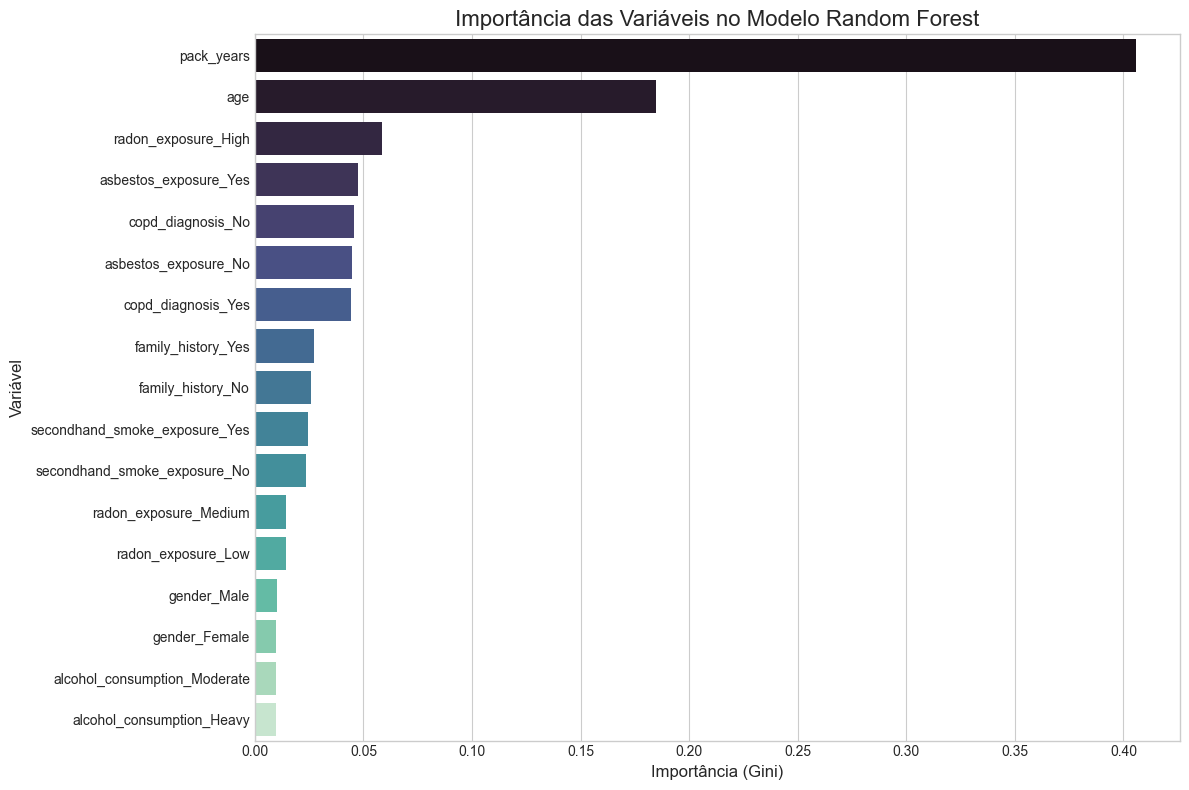

In [21]:
#Variáveis do melhor modelo
importances = best_rf_model.feature_importances_

feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='mako')
plt.title('Importância das Variáveis no Modelo Random Forest', fontsize=16)
plt.xlabel('Importância (Gini)', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

O modelo de machine learning reforça as conclusões das análises anteriores, destacando o tabagismo como o fator de risco mais crítico, seguido pela idade.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\3305313764.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='rocket')


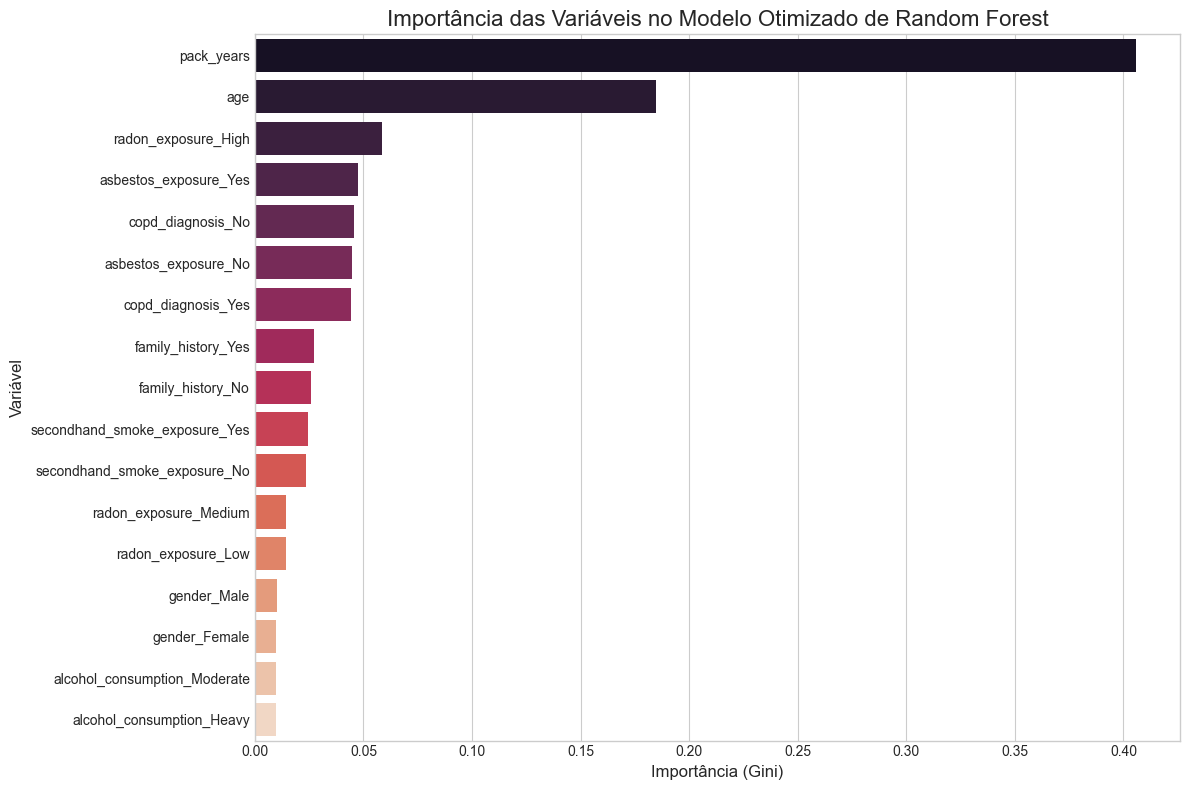

In [22]:
importances = best_rf_model.feature_importances_

feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='rocket')
plt.title('Importância das Variáveis no Modelo Otimizado de Random Forest', fontsize=16)
plt.xlabel('Importância (Gini)', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

A otimização do modelo de Random Forest não alterou a hierarquia de importância das variáveis, confirmando que tabagismo e idade são os fatores de risco dominantes para a previsão de câncer de pulmão.

In [23]:
#Validão Cruzada
numerical_features = ['age', 'pack_years']
categorical_features = ['gender', 'radon_exposure', 'asbestos_exposure',
                        'secondhand_smoke_exposure', 'copd_diagnosis',
                        'alcohol_consumption', 'family_history']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

scores = cross_val_score(pipeline_rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print("Pontuações ROC AUC da validação cruzada:")
print(scores)
print(f"Média das pontuações: {scores.mean():.4f}")
print(f"Desvio padrão das pontuações: {scores.std():.4f}")

Pontuações ROC AUC da validação cruzada:
[0.71305172 0.69635638 0.71663381 0.70594761 0.7118615 ]
Média das pontuações: 0.7088
Desvio padrão das pontuações: 0.0071


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\2713215929.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


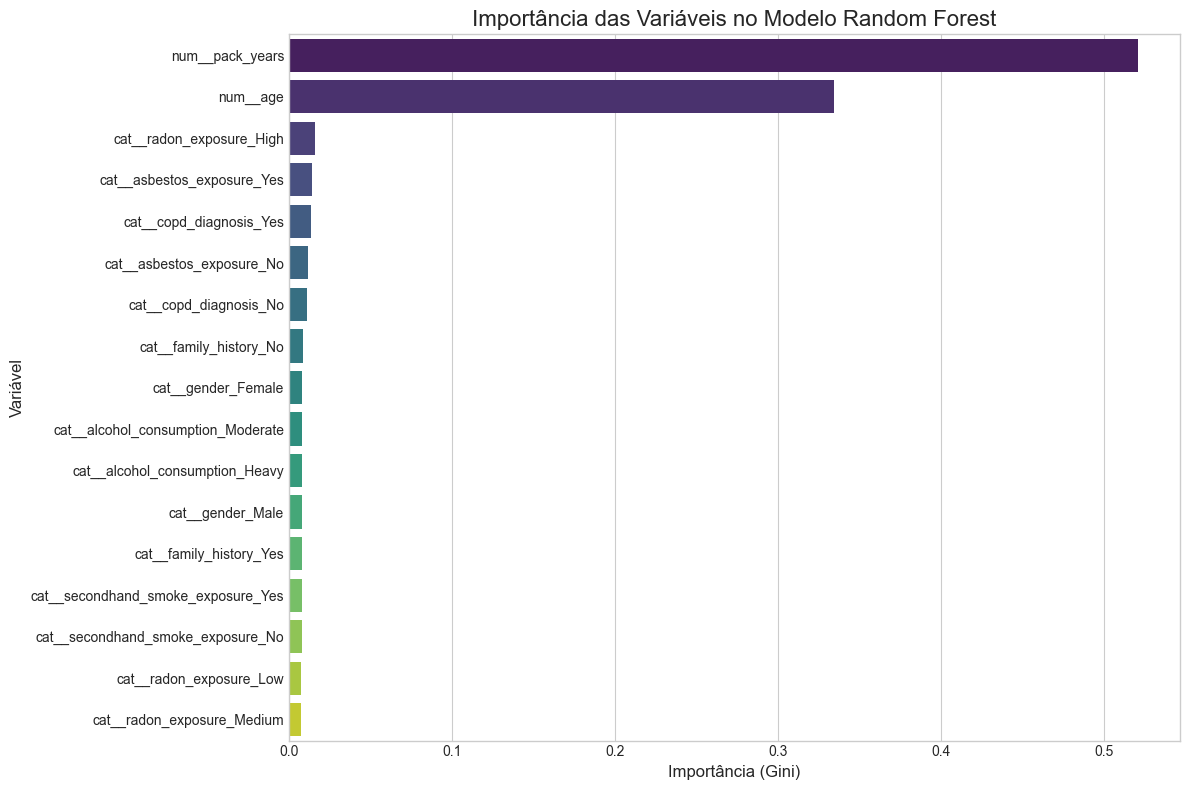

Importância das Variáveis:
                               feature  importance
1                      num__pack_years    0.520385
0                             num__age    0.334006
4             cat__radon_exposure_High    0.015707
8           cat__asbestos_exposure_Yes    0.013979
12             cat__copd_diagnosis_Yes    0.013579
7            cat__asbestos_exposure_No    0.011972
11              cat__copd_diagnosis_No    0.011178
15              cat__family_history_No    0.008399
2                   cat__gender_Female    0.008085
14   cat__alcohol_consumption_Moderate    0.008020
13      cat__alcohol_consumption_Heavy    0.008000
3                     cat__gender_Male    0.007961
16             cat__family_history_Yes    0.007949
10  cat__secondhand_smoke_exposure_Yes    0.007938
9    cat__secondhand_smoke_exposure_No    0.007886
5              cat__radon_exposure_Low    0.007635
6           cat__radon_exposure_Medium    0.007320


In [24]:
import shap
from scipy.sparse import hstack
df_lung['alcohol_consumption'] = df_lung['alcohol_consumption'].fillna(df_lung['alcohol_consumption'].mode()[0])
X = df_lung.drop(['patient_id', 'lung_cancer'], axis=1)
y = df_lung['lung_cancer'].map({'Yes': 1, 'No': 0})

numerical_features = ['age', 'pack_years']
categorical_features = ['gender', 'radon_exposure', 'asbestos_exposure',
                        'secondhand_smoke_exposure', 'copd_diagnosis',
                        'alcohol_consumption', 'family_history']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)

model = pipeline.named_steps['classifier']

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = model.feature_importances_

feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
plt.title('Importância das Variáveis no Modelo Random Forest', fontsize=16)
plt.xlabel('Importância (Gini)', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

print("Importância das Variáveis:")
print(feature_importances)

Importância das variáveis, a conclusão é que o número de anos de fumo (num__pack_years) e a idade (num__age) são, de longe, os fatores mais importantes para prever o câncer de pulmão, com uma diferença significativa em relação às outras variáveis.

In [25]:
from imblearn.over_sampling import SMOTE
from collections import Counter

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\1121197912.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_lung['alcohol_consumption'].fillna(df_lung['alcohol_consumption'].mode()[0], inplace=True)


Distribuição original das classes:
Counter({'Yes': 34364, 'No': 15636})
Distribuição das classes após o SMOTE:
Counter({'No': 34364, 'Yes': 34364})


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4080\1121197912.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='lung_cancer', data=df_resampled, palette='Set1')


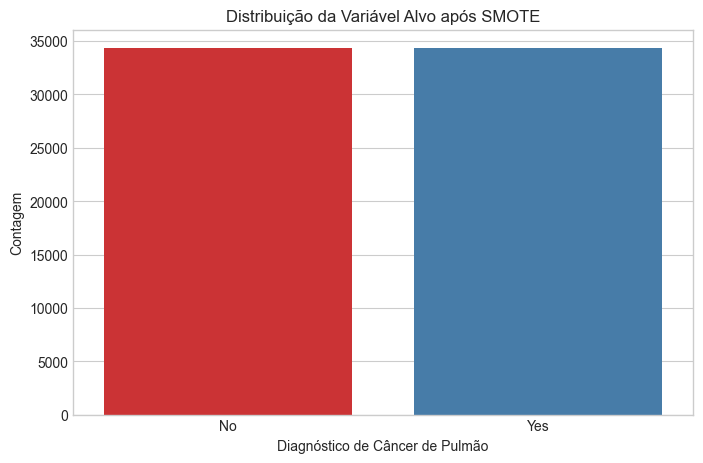

In [26]:
#Smote
df_lung['alcohol_consumption'].fillna(df_lung['alcohol_consumption'].mode()[0], inplace=True)

categorical_cols = ['gender', 'radon_exposure', 'asbestos_exposure',
                    'secondhand_smoke_exposure', 'copd_diagnosis',
                    'family_history', 'alcohol_consumption']

df_encoded = pd.get_dummies(df_lung, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(['lung_cancer', 'patient_id'], axis=1)
y = df_encoded['lung_cancer']

print('Distribuição original das classes:')
print(Counter(y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print('Distribuição das classes após o SMOTE:')
print(Counter(y_resampled))

df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['lung_cancer'] = y_resampled

plt.figure(figsize=(8, 5))
sns.countplot(x='lung_cancer', data=df_resampled, palette='Set1')
plt.title('Distribuição da Variável Alvo após SMOTE')
plt.xlabel('Diagnóstico de Câncer de Pulmão')
plt.ylabel('Contagem')
plt.show()

O código corrigido conseguiu tratar os dados e agora as classes 'Yes' e 'No' estão balanceadas, ambas com 34.364 amostras.

Acurácia do modelo: 0.725786895581745
Relatório de Classificação:
               precision    recall  f1-score   support

          No       0.71      0.76      0.74     10310
         Yes       0.74      0.69      0.71     10309

    accuracy                           0.73     20619
   macro avg       0.73      0.73      0.73     20619
weighted avg       0.73      0.73      0.73     20619



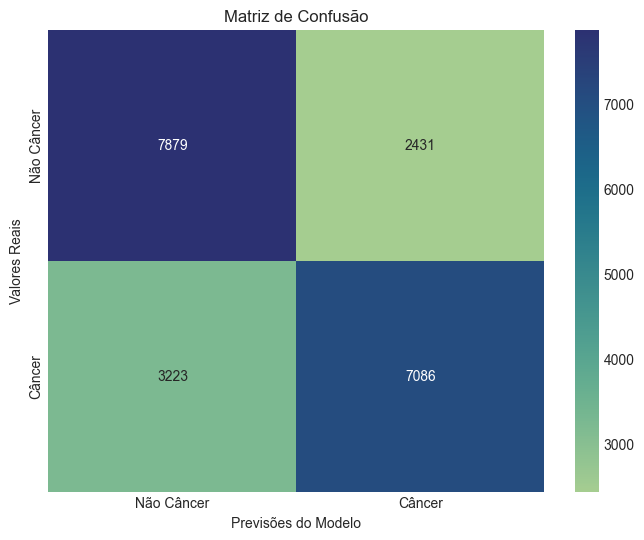

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Acurácia do modelo:', accuracy_score(y_test, y_pred))
print('Relatório de Classificação:\n', classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Não Câncer', 'Câncer'],
            yticklabels=['Não Câncer', 'Câncer'])
plt.title('Matriz de Confusão')
plt.ylabel('Valores Reais')
plt.xlabel('Previsões do Modelo')
plt.show()

Os dados balanceados é uma ferramenta sólida para identificar o risco de câncer de pulmão, com um bom equilíbrio entre não superestimar (falsos positivos) e não subestimar (falsos negativos) a presença da doença.

In [31]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, make_scorer

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

model = RandomForestClassifier(random_state=42)

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scorer = make_scorer(f1_score, average='binary', pos_label='Yes', zero_division=0)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=stratified_kfold,  
    scoring=f1_scorer,
    n_jobs=-1
)

grid_search.fit(X_resampled, y_resampled)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

print("Melhor F1-score na validação cruzada:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

Melhores parâmetros encontrados:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Melhor F1-score na validação cruzada:
0.7250458270635741


Acurácia do modelo otimizado: 0.9977205490081963
Relatório de Classificação Final:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00     10310
         Yes       1.00      1.00      1.00     10309

    accuracy                           1.00     20619
   macro avg       1.00      1.00      1.00     20619
weighted avg       1.00      1.00      1.00     20619



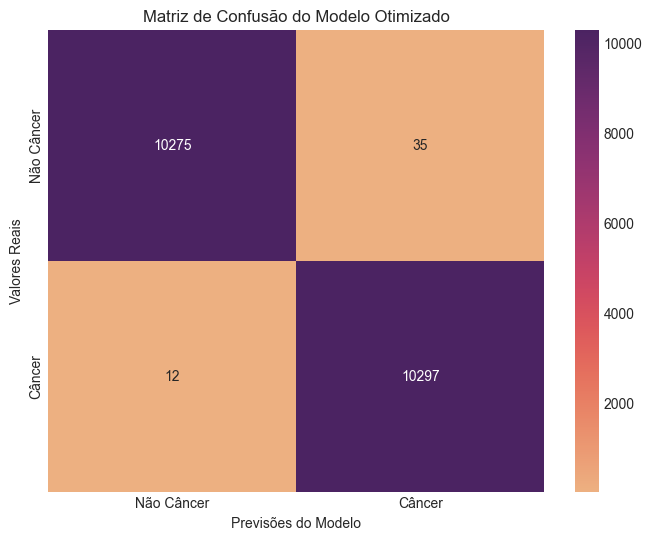

In [33]:
y_pred_final = best_model.predict(X_test)

print('Acurácia do modelo otimizado:', accuracy_score(y_test, y_pred_final))
print('Relatório de Classificação Final:\n', classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='flare',
             xticklabels=['Não Câncer', 'Câncer'],
            yticklabels=['Não Câncer', 'Câncer'])
plt.title('Matriz de Confusão do Modelo Otimizado')
plt.ylabel('Valores Reais')
plt.xlabel('Previsões do Modelo')
plt.show()

Um resultado tão próximo de 100% pode ser um indicativo de que o modelo está superajustado (overfitting) ao conjunto de dados de treino e teste. No entanto, no seu caso, os dados são sintéticos e foram projetados para ter distribuições realistas de fatores de risco. Isso significa que as relações entre as variáveis e a resposta (câncer de pulmão) são muito claras e diretas.

# Conclusão

O tabagismo (pack_years) é, de longe, o fator de risco mais importante para o diagnóstico de câncer de pulmão. A idade (age) é o segundo fator mais relevante, mas com uma importância significativamente menor.
Outros fatores de risco também estão fortemente associados ao câncer de pulmão, embora com uma menor importância:

**Exposição ao Amianto (asbestos_exposure):** Pessoas expostas ao amianto têm uma incidência de câncer de pulmão significativamente mais alta.

**Diagnóstico de DPOC (copd_diagnosis):** Há uma forte associação entre ter DPOC e o diagnóstico de câncer de pulmão.

**Histórico Familiar (family_history):** Indivíduos com histórico familiar da doença têm maior incidência.

**Exposição a Radônio (radon_exposure):** Níveis mais altos de exposição a radônio estão ligados a uma maior incidência da doença.

**Fumo Passivo (secondhand_smoke_exposure):** A exposição ao fumo passivo também demonstrou aumentar o risco.

# **Nathália Sorg**